# Examen Módulo 4
### Alumno: Salvador Calderón Martínez

## 1 Ingeniería de Datos, Integración (Join) y Publicación en la Nube (Parte 1)

### 1.1 Cargar datos

In [1]:
import pandas as pd

personal = pd.read_csv("https://raw.githubusercontent.com/anaepm/rep/refs/heads/main/nobel_personal.csv")
premios = pd.read_csv("https://raw.githubusercontent.com/anaepm/rep/refs/heads/main/nobel_data.csv")

print(personal.shape)
print(premios.shape)

(989, 15)
(989, 7)


In [2]:
personal.head()

,Laureate_Id,Firstname,Lastname,Gender,Birth_Date,Birth_Country,Birth_City,Birth_Country_Code,Death_Date,Death_Country,Death_City,Death_Country_Code,Organization_Name,Organization_City,Organization_Country
0,1,Wilhelm Conrad,Röntgen,male,1845-03-27,Prussia (now Germany),Lennep (now Remscheid),DE,10/02/1923,Germany,Munich,DE,Munich University,Munich,Germany
1,293,Emil,von Behring,male,1854-03-15,Prussia (now Poland),Hansdorf (now Lawice),PL,31/03/1917,Germany,Marburg,DE,Marburg University,Marburg,Germany
2,462,Henry,Dunant,male,1828-05-08,Switzerland,Geneva,CH,30/10/1910,Switzerland,Heiden,CH,NaN,NaN,NaN
3,463,Frédéric,Passy,male,1822-05-20,France,Paris,FR,12/06/1912,France,Paris,FR,NaN,NaN,NaN
4,569,Sully,Prudhomme,male,1839-03-16,France,Paris,FR,07/09/1907,France,Châtenay,FR,NaN,NaN,NaN


In [3]:
premios.head()

,Year,Laureate_Id,Firstname,Lastname,Category,Prize_Share,Motivation
0,1901,1,Wilhelm Conrad,Röntgen,physics,1,"""in recognition of the extraordinary services ..."
1,1901,293,Emil,von Behring,medicine,1,"""for his work on serum therapy especially its ..."
2,1901,462,Henry,Dunant,peace,2,"""for his humanitarian efforts to help wounded ..."
3,1901,463,Frédéric,Passy,peace,2,"""for his lifelong work for international peace..."
4,1901,569,Sully,Prudhomme,literature,1,"""in special recognition of his poetic composit..."


### 1.2 Análisis de datos

#### 1.2.1 Datos nulos

In [4]:
print(personal.isna().sum())
print(premios.isna().sum())

Laureate_Id               0
Firstname                 0
Lastname                 32
Gender                    0
Birth_Date                0
Birth_Country            31
Birth_City               33
Birth_Country_Code       31
Death_Date                0
Death_Country           343
Death_City              349
Death_Country_Code      343
Organization_Name       262
Organization_City       267
Organization_Country    265
dtype: int64
Year            0
Laureate_Id     0
Firstname       0
Lastname       32
Category        0
Prize_Share     0
Motivation      0
dtype: int64


#### 1.2.2 Datos duplicados

In [5]:
print("premios.duplicated():", premios.duplicated().sum())
print("personal.duplicated():", personal.duplicated().sum())
print("personal Laureate_Id duplicated:", personal["Laureate_Id"].duplicated().sum())
print("premios Laureate_Id duplicated:", premios["Laureate_Id"].duplicated().sum())

premios.duplicated(): 0
personal.duplicated(): 5
personal Laureate_Id duplicated: 8
premios Laureate_Id duplicated: 8


### 1.3 Limpieza

In [6]:
# Apellido vacío se le agrega "unknown" para no perder información
personal["Lastname"] = personal["Lastname"].fillna("unknown")
premios["Lastname"] = premios["Lastname"].fillna("unknown")

# Quitar espacios de más
personal["Firstname"] = personal["Firstname"].str.strip()
personal["Lastname"] = personal["Lastname"].str.strip()
premios["Firstname"] = premios["Firstname"].str.strip()
premios["Lastname"] = premios["Lastname"].str.strip()

In [7]:
# Elimino un identificador duplicado
personal = personal.drop_duplicates(subset="Laureate_Id")
personal.shape

(981, 15)

### 1.4 Realizar el Join

In [8]:
nobel = personal.merge(premios, on=["Firstname", "Lastname"], how="right", suffixes=("_x", "_y"))
nobel.head()

,Laureate_Id_x,Firstname,Lastname,Gender,Birth_Date,Birth_Country,Birth_City,Birth_Country_Code,Death_Date,Death_Country,Death_City,Death_Country_Code,Organization_Name,Organization_City,Organization_Country,Year,Laureate_Id_y,Category,Prize_Share,Motivation
0,1,Wilhelm Conrad,Röntgen,male,1845-03-27,Prussia (now Germany),Lennep (now Remscheid),DE,10/02/1923,Germany,Munich,DE,Munich University,Munich,Germany,1901,1,physics,1,"""in recognition of the extraordinary services ..."
1,293,Emil,von Behring,male,1854-03-15,Prussia (now Poland),Hansdorf (now Lawice),PL,31/03/1917,Germany,Marburg,DE,Marburg University,Marburg,Germany,1901,293,medicine,1,"""for his work on serum therapy especially its ..."
2,462,Henry,Dunant,male,1828-05-08,Switzerland,Geneva,CH,30/10/1910,Switzerland,Heiden,CH,NaN,NaN,NaN,1901,462,peace,2,"""for his humanitarian efforts to help wounded ..."
3,463,Frédéric,Passy,male,1822-05-20,France,Paris,FR,12/06/1912,France,Paris,FR,NaN,NaN,NaN,1901,463,peace,2,"""for his lifelong work for international peace..."
4,569,Sully,Prudhomme,male,1839-03-16,France,Paris,FR,07/09/1907,France,Châtenay,FR,NaN,NaN,NaN,1901,569,literature,1,"""in special recognition of his poetic composit..."


In [9]:
# No debe desaparecer ningún premio en el JOIN
print("Filas en nobel:", nobel.shape[0], " | Filas en premios:", premios.shape[0])
assert nobel.shape[0] == premios.shape[0], "El join perdió o duplicó premios -- revisa la celda anterior"

Filas en nobel: 989  | Filas en premios: 989


In [10]:
# Guardar
nobel.to_csv("nobel_limpio.csv", index=False, encoding="utf-8")
print("Guardado:", nobel.shape)
nobel.columns

Guardado: (989, 20)


Index(['Laureate_Id_x', 'Firstname', 'Lastname', 'Gender', 'Birth_Date',
       'Birth_Country', 'Birth_City', 'Birth_Country_Code', 'Death_Date',
       'Death_Country', 'Death_City', 'Death_Country_Code',
       'Organization_Name', 'Organization_City', 'Organization_Country',
       'Year', 'Laureate_Id_y', 'Category', 'Prize_Share', 'Motivation'],
      dtype='str')

In [11]:
# Consultar desde GitHub
nobel_publicado = pd.read_csv("https://raw.githubusercontent.com/SalvadorCM786/ExamenModuloIV/refs/heads/main/nobel_limpio.csv")
nobel_publicado.head()

,Laureate_Id_x,Firstname,Lastname,Gender,Birth_Date,Birth_Country,Birth_City,Birth_Country_Code,Death_Date,Death_Country,Death_City,Death_Country_Code,Organization_Name,Organization_City,Organization_Country,Year,Laureate_Id_y,Category,Prize_Share,Motivation
0,1,Wilhelm Conrad,Röntgen,male,1845-03-27,Prussia (now Germany),Lennep (now Remscheid),DE,10/02/1923,Germany,Munich,DE,Munich University,Munich,Germany,1901,1,physics,1,"""in recognition of the extraordinary services ..."
1,293,Emil,von Behring,male,1854-03-15,Prussia (now Poland),Hansdorf (now Lawice),PL,31/03/1917,Germany,Marburg,DE,Marburg University,Marburg,Germany,1901,293,medicine,1,"""for his work on serum therapy especially its ..."
2,462,Henry,Dunant,male,1828-05-08,Switzerland,Geneva,CH,30/10/1910,Switzerland,Heiden,CH,NaN,NaN,NaN,1901,462,peace,2,"""for his humanitarian efforts to help wounded ..."
3,463,Frédéric,Passy,male,1822-05-20,France,Paris,FR,12/06/1912,France,Paris,FR,NaN,NaN,NaN,1901,463,peace,2,"""for his lifelong work for international peace..."
4,569,Sully,Prudhomme,male,1839-03-16,France,Paris,FR,07/09/1907,France,Châtenay,FR,NaN,NaN,NaN,1901,569,literature,1,"""in special recognition of his poetic composit..."


## 2 Procesamiento de Lenguaje Natural (ETL de Texto y Visualización)

In [12]:
!pip install wordcloud -q

In [13]:
import re
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd
from wordcloud import STOPWORDS, WordCloud
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

premios = pd.read_csv(
    "https://raw.githubusercontent.com/SalvadorCM786/ExamenModuloIV/refs/heads/main/nobel_limpio.csv"
)
premios.groupby("Category")["Motivation"].describe()

,count,unique,top,freq
Category,,,,
chemistry,191,128,"""for their studies of extremely fast chemical ...",3
economics,92,60,"""for their pioneering work in the theory of fi...",3
literature,119,119,"""in special recognition of his poetic composit...",1
medicine,225,126,"""for their discoveries concerning liver therap...",3
peace,140,110,"""for their efforts to create peace in the Midd...",3
physics,222,141,"""for their researches on semiconductors and th...",3


In [14]:
# Revisar campos vacíos en Motivation
print("Campos vacíos en Motivation:", premios["Motivation"].isna().sum())
print(premios["Category"].value_counts())

# suma
texto_df = premios.dropna(subset=["Motivation"]).copy()
print("Total:", texto_df.shape[0])

Campos vacíos en Motivation: 0
Category
medicine      225
physics       222
chemistry     191
peace         140
literature    119
economics      92
Name: count, dtype: int64
Total: 989


### 2.1 Limpieza y normalización del texto


In [15]:
stopwords_en = set(STOPWORDS) | set(ENGLISH_STOP_WORDS)


def limpiar_texto(texto):
    texto = str(texto).lower()
    texto = re.sub(r"[^a-z\s]", " ", texto)   # quita puntuación, números y caracteres especiales
    texto = re.sub(r"\s+", " ", texto).strip()
    palabras = [w for w in texto.split() if w not in stopwords_en and len(w) > 2]
    return " ".join(palabras)


texto_df["Motivation_limpio"] = texto_df["Motivation"].apply(limpiar_texto)
texto_df[["Motivation", "Motivation_limpio"]].head()

,Motivation,Motivation_limpio
0,"""in recognition of the extraordinary services ...",recognition extraordinary services rendered di...
1,"""for his work on serum therapy especially its ...",work serum therapy especially application diph...
2,"""for his humanitarian efforts to help wounded ...",humanitarian efforts help wounded soldiers cre...
3,"""for his lifelong work for international peace...",lifelong work international peace conferences ...
4,"""in special recognition of his poetic composit...",special recognition poetic composition gives e...


### 2.2 Transformación

In [16]:
le = LabelEncoder()
texto_df["Label"] = le.fit_transform(texto_df["Category"])

# número de cada categoría
dict(zip(le.classes_, le.transform(le.classes_)))

{'chemistry': np.int64(0),
 'economics': np.int64(1),
 'literature': np.int64(2),
 'medicine': np.int64(3),
 'peace': np.int64(4),
 'physics': np.int64(5)}

### 2.3 Vectorización

In [17]:
mapa_palabras = " ".join(texto_df["Motivation_limpio"])
print("Total de palabras:", len(mapa_palabras.split()))


Total de palabras: 7631


In [18]:
vectorizador = TfidfVectorizer(
    stop_words="english",
    max_features=3000,
    min_df=2,         
    ngram_range=(1, 2) 
)

X = vectorizador.fit_transform(texto_df["Motivation_limpio"])
y = texto_df["Category"]

print("Matriz TF-IDF:", X.shape)
print("Ejemplo de términos:", vectorizador.get_feature_names_out()[:15])

Matriz TF-IDF: (989, 2610)
Ejemplo de términos: ['ability' 'ability poliomyelitis' 'abuse' 'abuse power' 'abuses'
 'abuses abuse' 'accelerated' 'accelerated atomic' 'accelerating'
 'accelerating expansion' 'achieve' 'achievement' 'achievement bose'
 'achievements' 'achievements development']


### 2.4 Generación y despliegue de la Nube de Palabras

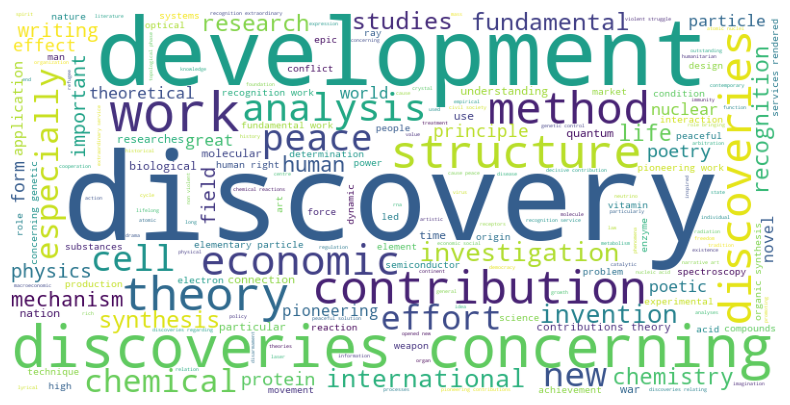

In [19]:
# nube de palabras
nube = WordCloud(width=800, height=400, background_color="white", stopwords=stopwords_en).generate(mapa_palabras)

plt.figure(figsize=(10, 5))
plt.imshow(nube)
plt.axis("off")
plt.show()

## 3 Modelado Predictivo, Evaluación y Matriz de Confusión


In [20]:
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
import numpy as np

### 3.1 Separar entrenamiento y prueba


In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Entrenamiento:", X_train.shape, " Prueba:", X_test.shape)

Entrenamiento: (791, 2610)  Prueba: (198, 2610)


### 3.2 Entrenar Naive Bayes

In [22]:
modelo = MultinomialNB()
modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9292929292929293


### 3.3 Métricas de clasificación

In [23]:
print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

   chemistry       0.92      0.95      0.94        38
   economics       1.00      0.89      0.94        18
  literature       1.00      0.92      0.96        24
    medicine       0.88      0.93      0.90        45
       peace       1.00      0.93      0.96        28
     physics       0.89      0.93      0.91        45

    accuracy                           0.93       198
   macro avg       0.95      0.92      0.94       198
weighted avg       0.93      0.93      0.93       198



### 3.4 Matriz de confusión

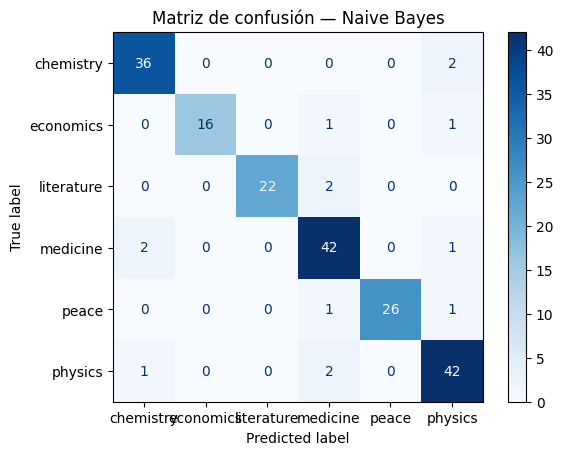

In [24]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")
plt.title("Matriz de confusión — Naive Bayes")
plt.show()

In [25]:
%%writefile app.py
import re

import pandas as pd
import streamlit as st
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

st.write(''' # Nobel Prize Category Prediction ''')

try:
    st.image("Nobel.png", caption="Created by Swedish inventor Alfred Nobel through his 1895 will.")
except Exception:
    st.caption("Created by Swedish inventor Alfred Nobel through his 1895 will.")

st.header("Text")

texto_usuario = st.text_input("Enter the motivation text to evaluate")


def limpiar_texto(texto):
    if pd.isna(texto):
        return ""
    texto = str(texto).lower()
    texto = re.sub(r"[^a-z\s]", " ", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto


nobel = pd.read_csv(
    "https://raw.githubusercontent.com/SalvadorCM786/ExamenModuloIV/refs/heads/main/nobel_limpio.csv"
)

nobel["Motivation"] = nobel["Motivation"].fillna("").astype(str)
nobel = nobel[nobel["Motivation"].str.strip().str.lower() != "nan"].copy()
nobel = nobel[nobel["Motivation"].str.strip() != ""].copy()

nobel["Text"] = nobel["Motivation"].apply(limpiar_texto)

nobel = nobel[nobel["Text"].str.strip() != ""].copy()

mapa_categorias = {'physics': 0, 'medicine': 1, 'peace': 2, 'literature': 3, 'chemistry': 4, 'economics': 5}
nobel["Label"] = nobel["Category"].map(mapa_categorias)

nobel = nobel.dropna(subset=["Label"]).copy()
nobel["Label"] = nobel["Label"].astype(int)

X = nobel["Text"]
y = nobel["Label"]

vect = CountVectorizer()
X_dtm = vect.fit_transform(X)

nb = MultinomialNB()
nb.fit(X_dtm, y)

if texto_usuario:
    texto_limpio = limpiar_texto(texto_usuario)
    df_dtm = vect.transform([texto_limpio])
    prediction = nb.predict(df_dtm)

    st.subheader("Prediction")
    if prediction[0] == 0:
        st.success("Physics")
    elif prediction[0] == 1:
        st.success("Medicine")
    elif prediction[0] == 2:
        st.success("Peace")
    elif prediction[0] == 3:
        st.success("Literature")
    elif prediction[0] == 4:
        st.success("Chemistry")
    elif prediction[0] == 5:
        st.success("Economics")
    else:
        st.warning("No prediction")
else:
    st.info("Enter text above to get a prediction.")


Overwriting app.py


## Enlace app streamlit
https://examenmoduloiv-qxitqgqjjvswxepnszqf8g.streamlit.app/